In [2]:
# ==========================================
# NOTEBOOK 13A
# ENTROPY CUT VALIDATION
# ==========================================
!pip install pennylane
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svdvals

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 89.4 MB/s eta 0:00:00


In [3]:
TEST_CASES = [

    (8,2,21),

    (10,6,4),

    (12,12,1),

    (14,2,13)

]

In [4]:
N_SAMPLES = 30

def entropy_at_cut(n, depth, cut):

    dev = qml.device(
        "default.qubit",
        wires=n
    )

    @qml.qnode(dev)
    def state_fn(params):

        BrickWall_HEA(
            n,
            params,
            depth
        )

        return qml.state()

    entropies = []

    left_dim = 2**cut
    right_dim = 2**(n-cut)

    for _ in range(N_SAMPLES):

        params = np.random.uniform(
            0,
            2*np.pi,
            size=n*depth
        )

        state = state_fn(params)

        psi = state.reshape(
            left_dim,
            right_dim
        )

        s = svdvals(psi)

        p = s**2

        p = p[p > 1e-12]

        entropy = -np.sum(
            p*np.log2(p)
        )

        entropies.append(entropy)

    return np.mean(entropies)

In [6]:
import pennylane as qml

# ==========================================
# BRICK WALL HARDWARE EFFICIENT ANSATZ
# ==========================================

def BrickWall_HEA(n_qubits, params, depth):

    idx = 0

    for d in range(depth):

        # Rotation layer
        for q in range(n_qubits):

            qml.RY(params[idx], wires=q)
            idx += 1

        # Brick-wall entangling layer
        if d % 2 == 0:

            for q in range(0, n_qubits-1, 2):
                qml.CNOT(wires=[q, q+1])

        else:

            for q in range(1, n_qubits-1, 2):
                qml.CNOT(wires=[q, q+1])


# ==========================================
# Observable
# ==========================================

def make_observable(k):

    op = qml.PauliZ(0)

    for q in range(1, k):

        op = op @ qml.PauliZ(q)

    return op

In [7]:
rows = []

for n,k,tau in TEST_CASES:

    cuts = {

        "k-1":max(1,k-1),

        "k":min(k,n-1),

        "k+1":min(n-1,k+1),

        "middle":n//2

    }

    print("="*60)
    print(f"n={n}  k={k}  tau={tau}")
    print("="*60)

    for label,cut in cuts.items():

        S = entropy_at_cut(

            n,

            tau,

            cut

        )

        print(f"{label:8s} cut={cut:2d}  S={S:.4f}")

        rows.append({

            "n":n,

            "k":k,

            "tau":tau,

            "cut":label,

            "cut_position":cut,

            "entropy":S

        })

entropy_df = pd.DataFrame(rows)

display(entropy_df)

n=8  k=2  tau=21
k-1      cut= 1  S=0.9292
k        cut= 2  S=1.7415
k+1      cut= 3  S=2.4834
middle   cut= 4  S=2.7338
n=10  k=6  tau=4
k-1      cut= 5  S=0.5526
k        cut= 6  S=0.8091
k+1      cut= 7  S=0.5489
middle   cut= 5  S=0.6049
n=12  k=12  tau=1
k-1      cut=11  S=0.3773
k        cut=11  S=0.1848
k+1      cut=11  S=0.2737
middle   cut= 6  S=-0.0000
n=14  k=2  tau=13
k-1      cut= 1  S=0.8584
k        cut= 2  S=1.4831
k+1      cut= 3  S=1.8677
middle   cut= 7  S=2.4113


,n,k,tau,cut,cut_position,entropy
0,8,2,21,k-1,1,9.292117e-01
1,8,2,21,k,2,1.741506e+00
2,8,2,21,k+1,3,2.483367e+00
3,8,2,21,middle,4,2.733793e+00
4,10,6,4,k-1,5,5.525709e-01
5,10,6,4,k,6,8.090653e-01
6,10,6,4,k+1,7,5.489276e-01
7,10,6,4,middle,5,6.049410e-01
8,12,12,1,k-1,11,3.773285e-01
9,12,12,1,k,11,1.847724e-01


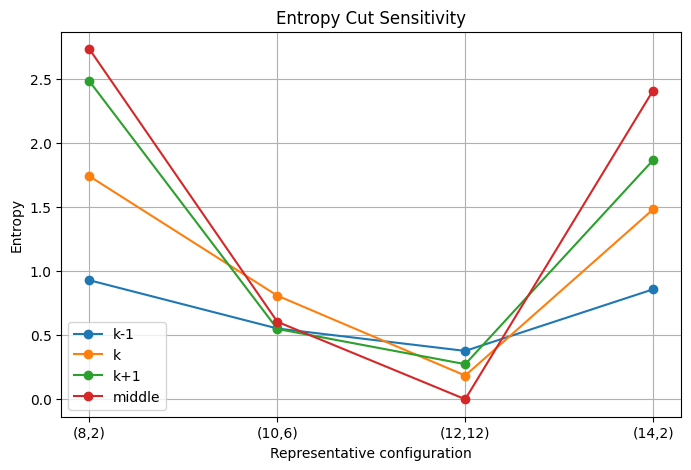

In [8]:
plt.figure(figsize=(8,5))

for label in entropy_df["cut"].unique():

    subset = entropy_df[
        entropy_df["cut"]==label
    ]

    plt.plot(

        range(len(subset)),

        subset["entropy"],

        marker="o",

        label=label

    )

plt.xticks(

    range(len(TEST_CASES)),

    [

        "(8,2)",

        "(10,6)",

        "(12,12)",

        "(14,2)"

    ]

)

plt.ylabel("Entropy")

plt.xlabel("Representative configuration")

plt.title("Entropy Cut Sensitivity")

plt.grid(True)

plt.legend()

plt.show()

In [9]:
print("="*60)
print("CUT SENSITIVITY")
print("="*60)

summary = entropy_df.groupby("cut")["entropy"].agg(

    ["mean","std"]

)

summary["CV"] = 100*summary["std"]/summary["mean"]

display(summary)

spread = entropy_df.groupby(

    ["n","k"]

)["entropy"].agg(

    lambda x: x.max()-x.min()

)

print("\nMaximum entropy spread across cuts")

display(spread)

print(f"\nAverage spread = {spread.mean():.4f}")

CUT SENSITIVITY


,mean,std,CV
cut,,,
k,1.054616,0.700561,66.428057
k+1,1.293442,1.055119,81.574534
k-1,0.679379,0.259346,38.173979
middle,1.437515,1.340183,93.229165



Maximum entropy spread across cuts


,,entropy
n,k,
8,2,1.804581
10,6,0.260138
12,12,0.377329
14,2,1.552924



Average spread = 0.9987
